# Teoría de curvas ROC y AUC

## De la probabilidad a la evaluación de un clasificador

Este notebook es un apunte teórico acompañado de un ejemplo reproducible. Estudiaremos cómo se construye una curva ROC, qué representa su área AUC y cómo distinguir una curva buena, una mediocre, una aleatoria y una invertida.

Usaremos datos sintéticos de pacientes: `1` significa que el paciente presenta una condición y `0` que no la presenta. No es un caso clínico real; se utiliza para aislar las ideas estadísticas.

## 1. Clasificar no es lo mismo que asignar una probabilidad

En clasificación binaria existen dos clases. Llamamos **positiva** a la clase de interés (`y = 1`) y **negativa** a la otra (`y = 0`). El término positivo no significa necesariamente algo deseable; solamente identifica la clase que decidimos detectar.

Un modelo suele producir primero un **score** o una probabilidad estimada. Por ejemplo, un paciente podría recibir una probabilidad de `0.73` de pertenecer a la clase positiva. Para convertir ese número en una decisión necesitamos un **umbral** o punto de corte:

$$\hat y = 1 \quad \text{si} \quad \hat p \ge c$$

donde $c$ es el umbral. Con $c=0.50$, una probabilidad de `0.73` se clasifica como positiva; con $c=0.80`, se clasifica como negativa. El modelo no cambió: cambió la regla de decisión.

Por eso, evaluar solamente las clases obtenidas con el umbral `0.50` ofrece una fotografía parcial. ROC estudia el modelo a través de **todos los umbrales posibles**.

## 2. Matriz de confusión: los cuatro resultados posibles

Para un umbral determinado, cada observación cae en una de cuatro categorías:

| Realidad | Predicción positiva | Predicción negativa |
|---|---:|---:|
| Positiva | Verdadero positivo (TP) | Falso negativo (FN) |
| Negativa | Falso positivo (FP) | Verdadero negativo (TN) |

- **TP:** el paciente tiene la condición y el modelo la detecta.
- **FN:** el paciente tiene la condición, pero el modelo no la detecta.
- **FP:** el paciente no tiene la condición, pero el modelo genera una alarma.
- **TN:** el paciente no tiene la condición y el modelo lo clasifica correctamente.

En `scikit-learn`, para clases `0` y `1`, el orden usual de `confusion_matrix` es:

```text
[[TN, FP],
 [FN, TP]]
```

Este orden debe revisarse antes de calcular métricas manualmente.

## 3. Sensibilidad, especificidad y tasa de falsos positivos

La **sensibilidad** pregunta qué proporción de los positivos reales detectó el modelo:

$$\text{Sensibilidad} = \text{TPR} = \frac{TP}{TP+FN}$$

También recibe los nombres de *recall* y *True Positive Rate*. Una sensibilidad alta implica pocos falsos negativos.

La **especificidad** pregunta qué proporción de los negativos reales fue reconocida correctamente:

$$\text{Especificidad} = \frac{TN}{TN+FP}$$

La curva ROC no coloca la especificidad directamente en el eje horizontal. Utiliza la **tasa de falsos positivos**:

$$\text{FPR} = \frac{FP}{FP+TN} = 1-\text{Especificidad}$$

Así, un punto ROC tiene coordenadas $(FPR, TPR)$. Nos interesa subir en el eje vertical sin avanzar demasiado en el horizontal: detectar más positivos con pocas falsas alarmas.

## 4. ¿Qué ocurre cuando cambia el umbral?

Si bajamos el umbral, es más fácil declarar un caso como positivo. Normalmente aumentan tanto los verdaderos positivos como los falsos positivos. Si subimos el umbral, el modelo exige más evidencia: disminuyen las falsas alarmas, pero también puede dejar escapar positivos reales.

| Umbral | Predice positivos | Sensibilidad | Falsos positivos |
|---|---|---|---|
| Muy alto | Muy pocos | Baja | Pocos |
| Intermedio | Algunos | Intermedia | Algunos |
| Muy bajo | Casi todos | Alta | Muchos |

No existe un umbral universalmente correcto. En una prueba de detección preliminar puede ser grave omitir un caso positivo; en otro contexto, una falsa alarma puede tener un costo mayor. La selección final depende de las consecuencias de FP y FN.

## 5. Construcción e interpretación de la curva ROC

ROC significa *Receiver Operating Characteristic*. Para construir la curva:

1. Se ordenan los casos según su score, de mayor a menor.
2. Se prueban distintos umbrales.
3. Para cada umbral se calcula `TPR` y `FPR`.
4. Se grafican los puntos $(FPR, TPR)$ y se conectan.

La curva comienza en `(0, 0)`: un umbral tan alto que nadie es clasificado como positivo. Termina en `(1, 1)`: un umbral tan bajo que todos son clasificados como positivos.

El punto ideal es `(0, 1)`: sensibilidad igual a uno y cero falsos positivos. Cuanto más pronto se acerque la curva a la esquina superior izquierda, mejor separa el modelo las clases. La diagonal de `(0, 0)` a `(1, 1)` representa un ordenamiento sin capacidad discriminante, similar al azar.

## 6. AUC: resumir toda la curva en un número

AUC significa *Area Under the Curve*: el área bajo la curva ROC. Sus valores relevantes suelen estar entre `0` y `1`.

La interpretación más útil no es solamente geométrica. Si elegimos al azar un individuo positivo y uno negativo, el AUC es la probabilidad de que el modelo asigne un score mayor al positivo. Por tanto, AUC mide la capacidad de **ordenar** ambas clases.

| AUC aproximado | Interpretación |
|---:|---|
| `1.00` | Ordenamiento perfecto |
| `0.80 - 0.90` | Buena separación |
| `0.70 - 0.80` | Separación aceptable |
| `0.60 - 0.70` | Separación débil |
| `0.50` | Sin discriminación, similar al azar |
| Menor que `0.50` | Ordenamiento predominantemente invertido |

Estas etiquetas son orientativas, no reglas universales. La exigencia depende de la aplicación. Un AUC alto tampoco garantiza probabilidades bien calibradas ni indica qué umbral debemos elegir.

## 7. Ventajas, límites y errores frecuentes

**Ventajas:** AUC compara modelos sin fijar primero un umbral, resume muchos puntos operativos y no cambia si aplicamos al score una transformación estrictamente creciente que conserve el orden.

**Límites:** no selecciona el umbral, no mide calibración, no incorpora por sí sola el costo de los errores y puede resultar demasiado optimista cuando la clase positiva es muy rara. En problemas muy desbalanceados conviene revisar también precisión, recall y la curva Precision-Recall.

**Errores frecuentes:**

- Calcular ROC con `predict()` en vez de usar `predict_proba()` o `decision_function()`.
- Usar la probabilidad de la clase `0` cuando la clase positiva es `1`.
- Confundir especificidad con FPR: son complementarias, no iguales.
- Evaluar sobre los mismos datos usados para entrenar.
- Concluir que dos modelos con AUC parecida se comportan igual en el umbral que importa. Sus curvas pueden cruzarse.

A continuación veremos estas ideas en un ejemplo controlado.

## 8. Preparación de los datos

Generamos observaciones con varias mediciones. Algunas contienen informacion sobre la clase y otras agregan ruido. Separamos entrenamiento y prueba para evaluar con pacientes que el modelo no vio durante el ajuste.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=1500, n_features=10, n_informative=6, n_redundant=2,
    class_sep=1.1, flip_y=0.08, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((975, 10), (525, 10))

## 9. Cuatro maneras de asignar scores

Compararemos cuatro situaciones:

1. **Modelo bueno:** regresion logistica usando todas las variables.
2. **Modelo intermedio:** el mismo metodo, pero usando solo una variable.
3. **Modelo aleatorio:** scores al azar; representa no tener informacion.
4. **Modelo invertido:** usa `1 - probabilidad` del modelo bueno; ordena las clases al reves.

La curva ROC utiliza scores o probabilidades, no las clases finales obtenidas con un corte de 0.5.

In [2]:
modelo_bueno = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
modelo_bueno.fit(X_train, y_train)
score_bueno = modelo_bueno.predict_proba(X_test)[:, 1]

modelo_intermedio = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
modelo_intermedio.fit(X_train[:, [0]], y_train)
score_intermedio = modelo_intermedio.predict_proba(X_test[:, [0]])[:, 1]

rng = np.random.default_rng(42)
score_aleatorio = rng.random(len(y_test))
score_invertido = 1 - score_bueno

scores = {
    'Bueno': score_bueno,
    'Intermedio': score_intermedio,
    'Aleatorio': score_aleatorio,
    'Invertido': score_invertido,
}

{nombre: round(roc_auc_score(y_test, score), 3) for nombre, score in scores.items()}

{'Bueno': 0.893, 'Intermedio': 0.524, 'Aleatorio': 0.482, 'Invertido': 0.107}

## 10. Dibujamos las curvas ROC

La esquina superior izquierda representa alta sensibilidad con pocos falsos positivos. La diagonal punteada representa el comportamiento esperado de un clasificador aleatorio.

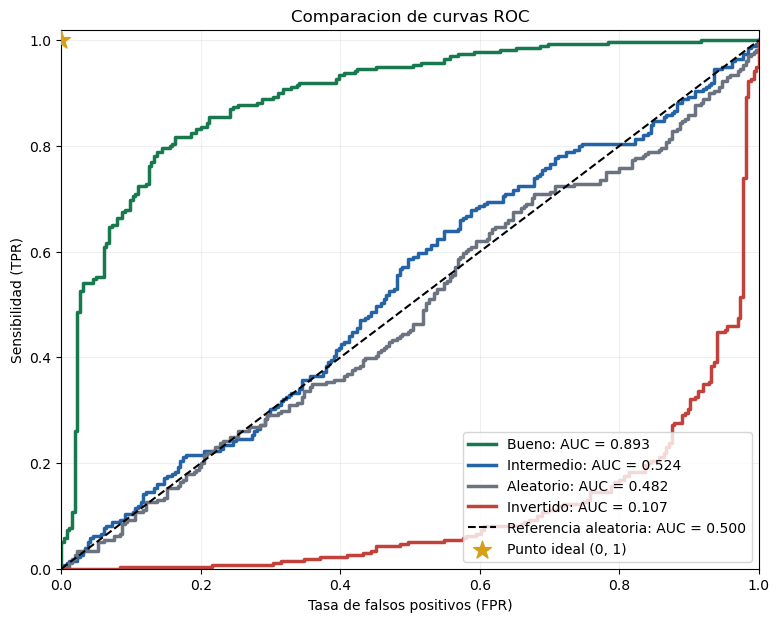

In [3]:
colores = {
    'Bueno': '#18794e',
    'Intermedio': '#2463a6',
    'Aleatorio': '#6b7280',
    'Invertido': '#c2413b',
}

plt.figure(figsize=(9, 7))
for nombre, score in scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, linewidth=2.5, color=colores[nombre],
             label=f'{nombre}: AUC = {auc:.3f}')

plt.plot([0, 1], [0, 1], '--', color='black', linewidth=1.5,
         label='Referencia aleatoria: AUC = 0.500')
plt.scatter([0], [1], marker='*', s=180, color='#d4a017',
            label='Punto ideal (0, 1)', zorder=5)
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Sensibilidad (TPR)')
plt.title('Comparacion de curvas ROC')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.grid(alpha=0.2)
plt.legend(loc='lower right')
plt.show()

## 11. Cómo interpretar la figura

- **Buena:** se arquea hacia la esquina superior izquierda. Consigue detectar muchos positivos antes de acumular demasiados falsos positivos.
- **Intermedia:** permanece por encima de la diagonal, pero ofrece menor separacion. Tiene informacion util, aunque limitada.
- **Aleatoria:** oscila alrededor de la diagonal. Cambiar el corte no produce una ventaja consistente.
- **Invertida:** queda debajo de la diagonal y su AUC es menor que 0.5. Asigna scores altos principalmente a los negativos.

Una curva debajo de la diagonal puede revelar un error de orientacion: clase positiva mal definida, columna equivocada de `predict_proba` o score interpretado al reves. Al invertir el score, el AUC cambia aproximadamente de `AUC` a `1 - AUC`.

## 12. Una curva ROC no elige el corte por nosotros

Cada punto de la curva corresponde a un corte distinto. Podemos buscar un punto equilibrado con el indice de Youden, `TPR - FPR`, pero en una aplicacion real el corte debe considerar el costo de los errores.

In [4]:
fpr, tpr, cortes = roc_curve(y_test, score_bueno)
indice = np.argmax(tpr - fpr)

print(f'Corte sugerido por Youden: {cortes[indice]:.3f}')
print(f'Sensibilidad en ese punto: {tpr[indice]:.3f}')
print(f'Especificidad en ese punto: {1 - fpr[indice]:.3f}')

Corte sugerido por Youden: 0.504
Sensibilidad en ese punto: 0.816
Especificidad en ese punto: 0.837


## 13. Preguntas para discutir en clase

1. ¿Por que la curva invertida queda debajo de la diagonal?
2. ¿Un AUC alto garantiza que el corte 0.5 sea adecuado?
3. ¿Que corte elegirian si un falso negativo fuera mucho mas costoso?
4. ¿Por que evaluamos con datos que el modelo no uso para entrenar?
5. ¿Que revisarian primero si obtuvieran un AUC de 0.15?

**Idea central:** AUC evalua que tan bien se ordenan positivos y negativos a traves de todos los cortes; no sustituye la decision sobre el corte operativo.